In [1]:
!pip install transformers torch scikit-learn matplotlib seaborn

In [2]:
import torch
from transformers import CLIPTokenizer, CLIPModel

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [ ]:
import torch, random, numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def _extract_text_tensor(out):
    """
    Compatibilidade entre transformers 4.x e 5.x.

    MUDANÇA INCOMPATÍVEL: em transformers <= 4.57, get_text_features()
    retornava um torch.Tensor [batch, 512] (embedding já projetado).
    Em transformers >= 5.x, retorna um objeto BaseModelOutputWithPooling
    (dataclass), sem métodos de tensor como .norm() / .detach() —
    daí o erro 'BaseModelOutputWithPooling object has no attribute norm'.

    Nas versões 5.x o embedding projetado fica em .pooler_output.
    Esta função normaliza os dois casos para SEMPRE devolver o tensor
    projetado [batch, 512], que é o espaço multimodal correto para
    comparar texto (o mesmo usado pelo Stable Diffusion).
    """
    if isinstance(out, torch.Tensor):
        return out                                  # transformers 4.x
    # transformers 5.x: BaseModelOutputWithPooling
    if getattr(out, "pooler_output", None) is not None:
        return out.pooler_output
    # fallback : alguns forks expõem só last_hidden_state
    if getattr(out, "last_hidden_state", None) is not None:
        return out.last_hidden_state[:, -1, :]
    raise TypeError(f"Formato de saída inesperado: {type(out)}")

def get_text_embedding(text):
    inputs = tokenizer(text=[text], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        out = model.get_text_features(**inputs)
    emb = _extract_text_tensor(out)                 
    emb = emb / emb.norm(dim=-1, keepdim=True)     
    return emb.squeeze(0).cpu()

def get_text_embeddings_batch(texts):
    """Versão em lote: uma chamada do modelo para N strings. [N, 512] L2-norm."""
    inputs = tokenizer(text=list(texts), return_tensors="pt",
                       padding=True).to(device)
    with torch.no_grad():
        out = model.get_text_features(**inputs)
    emb = _extract_text_tensor(out)
    emb = emb / emb.norm(dim=-1, keepdim=True)
    return emb.cpu()

In [ ]:
import numpy as np

def similarity(a, b):
    """
    Cosseno entre dois vetores. Aceita torch.Tensor ou np.ndarray.
    Como os embeddings já são L2-normalizados, o cosseno é só o produto
    interno — mas mantemos a normalização defensiva para o caso de
    receber vetores não-normalizados (ex.: diferenças de vetores).
    """
    a = np.asarray(a, dtype=np.float64).ravel()
    b = np.asarray(b, dtype=np.float64).ravel()
    na, nb_ = np.linalg.norm(a), np.linalg.norm(b)
    if na < 1e-8 or nb_ < 1e-8:
        return float("nan")   # evita ruído amplificado por divisão ~0
    return float(np.dot(a, b) / (na * nb_))

def cos_matrix(M, v):
    """Cosseno de cada linha de M (já normalizado) com vetor v (idem)."""
    M = np.asarray(M, dtype=np.float64)
    v = np.asarray(v, dtype=np.float64).ravel()
    return M @ v

In [23]:
a = get_text_embedding("green frog")
b = get_text_embedding("red frog")
c = get_text_embedding("green car")

print("green frog vs red frog: ", similarity(a, b))
print("green frog vs green car: ", similarity(a, c))

green frog vs red frog:  0.77381694
green frog vs green car:  0.832236


In [ ]:
# ─────────────────────────────────────────────────────────────
# TESTE DE COMPOSICIONALIDADE VETORIAL — sondagem exploratória
# ─────────────────────────────────────────────────────────────


def raw_embedding(text):
    inputs = tokenizer(text=[text], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        out = model.get_text_features(**inputs)
    emb = _extract_text_tensor(out)        
    return emb.squeeze(0).cpu().numpy()

frog_r       = raw_embedding("frog")
green_frog_r = raw_embedding("green frog")
car_r        = raw_embedding("car")
green_car_r  = raw_embedding("green car")

v1 = green_frog_r - frog_r
v2 = green_car_r  - car_r

print("Sondagem exploratória do 'vetor verde' (NÃO conclusiva):")
print(f"  ||green_frog - frog|| = {np.linalg.norm(v1):.3f}")
print(f"  ||green_car  - car||  = {np.linalg.norm(v2):.3f}")
print(f"  cos(v1, v2)           = {similarity(v1, v2):.3f}")
print("  -> ver ressalva no comentário: interpretar com cautela.")

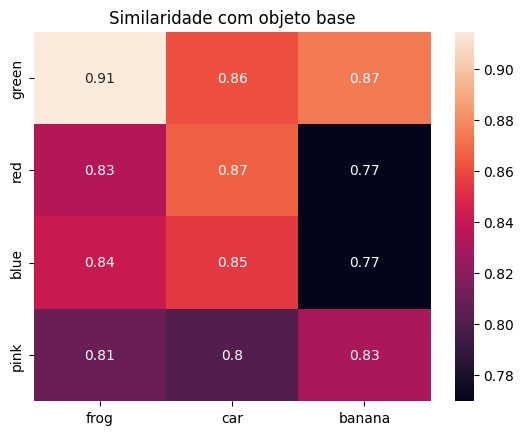

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

objects = ["frog", "car", "banana"]
colors = ["green", "red", "blue", "pink"]

matrix = []

for color in colors:
  row = []
  for obj in objects:
    embedding = get_text_embedding(f"{color} {obj}")
    base = get_text_embedding(obj)
    row.append(similarity(embedding, base))
  matrix.append(row)

sns.heatmap(matrix, annot=True, xticklabels=objects, yticklabels=colors)
plt.title("Similaridade com objeto base")
plt.show()

In [29]:
def binding_test(obj1, obj2, color1, color2):
  A = get_text_embedding(f"{color1} {obj1}")
  B = get_text_embedding(f"{color2} {obj2}")
  C = get_text_embedding(f"{color1} {obj2}")

  similarity_obj = similarity(A, B)
  similarity_color = similarity(A, C)

  print(f"\nTeste: '{color1} {obj1}'")
  print(f"vs '{color2} {obj1}' (mesmo objeto): {similarity_obj:.3f}")
  print(f"vs '{color1} {obj2}' (mesma cor):   {similarity_color:.3f}")

  if similarity_obj > similarity_color:
      print("Objeto domina (binding melhor)")
  elif similarity_color > similarity_obj:
      print("Cor domina (binding fraco)")
  else:
      print("Empate (ambíguo)")

  return similarity_obj, similarity_color

In [31]:
deltas = []

tests = [
    ("frog", "car", "green", "red"),
    ("banana", "car", "yellow", "blue"),
    ("apple", "banana", "red", "green"),
    ("frog", "banana", "green", "blue"),
]

for obj1, obj2, c1, c2 in tests:
  similarity_obj, similarity_color = binding_test(obj1, obj2, c1, c2)
  deltas.append(similarity_obj - similarity_color)

binding_score = sum(deltas) / len(deltas)

print("\nBinding Score médio:", round(binding_score, 3))


Teste: 'green frog'
vs 'red frog' (mesmo objeto): 0.661
vs 'green car' (mesma cor):   0.832
Cor domina (binding fraco)

Teste: 'yellow banana'
vs 'blue banana' (mesmo objeto): 0.686
vs 'yellow car' (mesma cor):   0.846
Cor domina (binding fraco)

Teste: 'red apple'
vs 'green apple' (mesmo objeto): 0.734
vs 'red banana' (mesma cor):   0.796
Cor domina (binding fraco)

Teste: 'green frog'
vs 'blue frog' (mesmo objeto): 0.656
vs 'green banana' (mesma cor):   0.821
Cor domina (binding fraco)

Binding Score médio: -0.139


In [32]:
import random

objects = ["frog", "car", "banana", "apple"]
colors = ["green", "red", "blue", "yellow"]

results = []

for _ in range(50):
    obj1, obj2 = random.sample(objects, 2)
    c1, c2 = random.sample(colors, 2)

    A = get_text_embedding(f"{c1} {obj1}")
    B = get_text_embedding(f"{c2} {obj1}")
    C = get_text_embedding(f"{c1} {obj2}")

    sim_obj = similarity(A, B)
    sim_color = similarity(A, C)

    results.append(sim_obj - sim_color)

print("Binding médio:", sum(results)/len(results))

Binding médio: -0.00108513


In [33]:
import random
import numpy as np

def binding_delta(obj1, obj2, c1, c2):
    A = get_text_embedding(f"{c1} {obj1}")
    B = get_text_embedding(f"{c2} {obj1}")  # troca cor
    C = get_text_embedding(f"{c1} {obj2}")  # troca objeto

    sim_obj = similarity(A, B)
    sim_color = similarity(A, C)

    return sim_obj - sim_color

In [34]:
objects = ["frog", "car", "banana", "apple", "dog", "chair"]
colors = ["green", "red", "blue", "yellow", "black", "white"]

deltas = []

for _ in range(1000):
    obj1, obj2 = random.sample(objects, 2)
    c1, c2 = random.sample(colors, 2)

    d = binding_delta(obj1, obj2, c1, c2)
    deltas.append(d)

mean = np.mean(deltas)
std = np.std(deltas)

print("Binding mean:", mean)
print("Std:", std)

Binding mean: 0.019623268
Std: 0.05674077


In [ ]:
# ═════════════════════════════════════════════════════════════
# BASELINES DE ANCORAGEM
# ═════════════════════════════════════════════════════════════

#   - LIMITE SUPERIOR: similaridade entre paráfrases do MESMO conteúdo
#                      (CLIP deveria ver como quase idênticas)
#   - LIMITE INFERIOR: similaridade entre conteúdos NÃO relacionados
#                      (CLIP deveria ver como distantes)


ref_objects = ["frog", "car", "banana", "apple", "dog", "chair"]
ref_colors  = ["green", "red", "blue", "yellow", "black", "white"]

# Limite superior: mesmo conceito, fraseado diferente
para_pairs = [
    ("a green frog", "a frog that is green"),
    ("a red car",    "a car that is red"),
    ("a blue chair", "a chair colored blue"),
    ("a yellow banana", "a banana that is yellow"),
]
upper = []
for s1, s2 in para_pairs:
    e = get_text_embeddings_batch([s1, s2])
    upper.append(similarity(e[0], e[1]))

# Limite inferior: conceitos sem relação
unrel_pairs = [
    ("a green frog", "a red car"),
    ("a blue chair", "a yellow banana"),
    ("a black dog",  "a white apple"),
    ("a red apple",  "a green chair"),
]
lower = []
for s1, s2 in unrel_pairs:
    e = get_text_embeddings_batch([s1, s2])
    lower.append(similarity(e[0], e[1]))

upper_mean = float(np.mean(upper))
lower_mean = float(np.mean(lower))

print("=== BASELINES DE ANCORAGEM ===")
print(f"Limite SUPERIOR (paráfrases do mesmo conceito): {upper_mean:.3f}")
print(f"Limite INFERIOR (conceitos não relacionados):   {lower_mean:.3f}")
print(f"Faixa dinâmica do espaço CLIP-texto:            {upper_mean - lower_mean:.3f}")
print()
print("Interpretação: qualquer similaridade de binding deve ser lida")
print("RELATIVA a esses âncoras, não em valor absoluto. Se 'green frog'")
print("vs 'red frog' (troca de cor) ficar perto do limite SUPERIOR, o")
print("CLIP é quase cego à cor — sinal de binding fraco.")

In [ ]:
# ═════════════════════════════════════════════════════════════
# TESTE CENTRAL DE BINDING: ATRIBUTOS CRUZADOS EM FRASE MULTI-OBJETO
# ═════════════════════════════════════════════════════════════

#
#   O CLIP distingue  "a {c1} {o1} and a {c2} {o2}"
#              de      "a {c2} {o1} and a {c1} {o2}"  (cores TROCADAS)?
#
# Mesmas palavras, mesma estrutura — só o BINDING cor->objeto muda.
# Se a similaridade entre as duas for ~ limite SUPERIOR, o CLIP NÃO
# representa qual cor pertence a qual objeto: binding cego.

import itertools

cross_sims = []
examples = []

obj_pairs   = list(itertools.combinations(ref_objects, 2))
color_pairs = list(itertools.combinations(ref_colors, 2))

for (o1, o2) in obj_pairs:
    for (c1, c2) in color_pairs:
        s_correct = f"a {c1} {o1} and a {c2} {o2}"
        s_swapped = f"a {c2} {o1} and a {c1} {o2}"   # cores trocadas
        e = get_text_embeddings_batch([s_correct, s_swapped])
        sim = similarity(e[0], e[1])
        cross_sims.append(sim)
        if len(examples) < 6:
            examples.append((s_correct, s_swapped, sim))

cross_sims = np.array(cross_sims)

print("=== BINDING CRUZADO (frase multi-objeto, cores trocadas) ===")
print(f"Pares avaliados: {len(cross_sims)}")
print(f"Similaridade média correto-vs-trocado: {cross_sims.mean():.3f} "
      f"(std {cross_sims.std():.3f})")
print(f"Limite SUPERIOR (paráfrase):           {upper_mean:.3f}")
print(f"Limite INFERIOR (não relacionado):     {lower_mean:.3f}")
print()

# Posição relativa entre os âncoras: 1.0 = cego ao binding, 0.0 = binding perfeito
blindness = (cross_sims.mean() - lower_mean) / (upper_mean - lower_mean)
print(f"Índice de cegueira ao binding: {blindness:.2%}")
print("(100% = CLIP não distingue cores trocadas | 0% = distingue perfeitamente)")
print()
print("Exemplos:")
for sc, ss, sm in examples:
    print(f"  sim={sm:.3f} | '{sc}'  vs  '{ss}'")

plt.figure(figsize=(7,4))
plt.hist(cross_sims, bins=30, alpha=0.8)
plt.axvline(upper_mean, color="green", linestyle="--", label=f"Sup. (paráfrase) {upper_mean:.2f}")
plt.axvline(lower_mean, color="red",   linestyle="--", label=f"Inf. (não relac.) {lower_mean:.2f}")
plt.axvline(cross_sims.mean(), color="black", linestyle="-", label=f"Média cruzada {cross_sims.mean():.2f}")
plt.title("Binding Cruzado: correto vs cores trocadas")
plt.xlabel("similaridade de cosseno")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

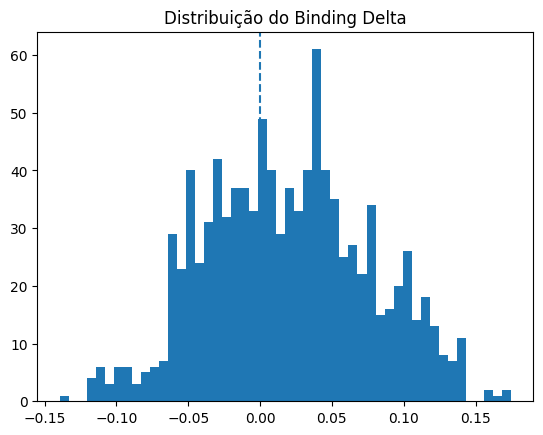

In [35]:
plt.hist(deltas, bins=50)
plt.title("Distribuição do Binding Delta")
plt.axvline(0, linestyle="--")
plt.show()